# 08 — 精度全覽：FP32 / FP16 / BF16 / INT8 / FP8

使用 trtexec 建立並 benchmark 所有 TensorRT 支援的壓縮精度引擎，比較速度與（選用）預測一致性。

| 精度 | 旗標 | 說明 | GPU 要求 |
|------|------|------|---------|
| FP32 | 無 | TensorRT 預設，完整精度 | 所有 GPU |
| FP16 | `--fp16` | 半精度浮點，最常用 | Pascal+ |
| BF16 | `--bf16` | Brain Float 16，指數範圍更大 | Hopper+ / Blackwell |
| INT8 | `--int8` | 8-bit 整數；需校準以保精度 | Turing+ |
| FP8  | `--fp8`  | 8-bit 浮點（E4M3），最小 footprint | Ada+ / Blackwell |

> **注意**：INT8 未提供校準資料集時，trtexec 以合成資料做 PTQ。引擎可建立、速度數據有效，但精度可能下降。

## 1. 路徑設定

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src.env import *
setup_matplotlib()

ENGINES_DIR = Path("engines/precision")
ENGINES_DIR.mkdir(parents=True, exist_ok=True)

MAX_IMAGES = 100

assert TRTEXEC.exists(),    f"trtexec not found: {TRTEXEC}"
assert ONNX_MODEL.exists(), f"ONNX model not found: {ONNX_MODEL}"
print("Paths OK")
print(f"  Engines dir: {ENGINES_DIR}")

Font loaded: Cubic 11  (D:\tensorrt\book\src\fonts\Cubic_11.ttf)
Paths OK
  Engines dir: engines\precision


## 2. ONNX 模型 Shape 確認

In [2]:
import onnx

model = onnx.load(str(ONNX_MODEL))
onnx.checker.check_model(model)

def fmt_shape(tensor_type):
    dims = tensor_type.shape.dim
    return [d.dim_value if d.dim_value > 0 else (d.dim_param or "?") for d in dims]

print(f"Opset: {model.opset_import[0].version}")
for t in model.graph.input:
    print(f"Input : {t.name}  {fmt_shape(t.type.tensor_type)}")
for t in model.graph.output:
    print(f"Output: {t.name}  {fmt_shape(t.type.tensor_type)}")

_shape = fmt_shape(model.graph.input[0].type.tensor_type)
MODEL_C = _shape[1] if isinstance(_shape[1], int) else 3
MODEL_H = _shape[2] if isinstance(_shape[2], int) else 448
MODEL_W = _shape[3] if isinstance(_shape[3], int) else 448
print(f"\nInference shape: [1, {MODEL_C}, {MODEL_H}, {MODEL_W}]")

Opset: 12
Input : images  [1, 3, 448, 448]
Output: output  [1, 6]

Inference shape: [1, 3, 448, 448]


## 3. 工具函式

In [3]:
import subprocess, re, time


def parse_trtexec(stdout: str) -> dict:
    patterns = {
        "mean_ms":        r"mean\s*=\s*([\d.]+)\s*ms",
        "median_ms":      r"median\s*=\s*([\d.]+)\s*ms",
        "p95_ms":         r"percentile\(95%\)\s*=\s*([\d.]+)\s*ms",
        "p99_ms":         r"percentile\(99%\)\s*=\s*([\d.]+)\s*ms",
        "throughput_qps": r"Throughput:\s*([\d.]+)\s*qps",
        "gpu_compute_ms": r"GPU Compute Time.*?mean\s*=\s*([\d.]+)\s*ms",
    }
    return {
        k: float(m.group(1))
        for k, pat in patterns.items()
        if (m := re.search(pat, stdout, re.IGNORECASE))
    }


def build_engine(onnx_path: Path, engine_path: Path, extra_flags=()) -> bool:
    """Build TRT engine with trtexec. Returns True on success."""
    cmd = [
        str(TRTEXEC),
        f"--onnx={onnx_path}",
        f"--saveEngine={engine_path}",
        "--skipInference",
        *extra_flags,
    ]
    print(f"  Building: {engine_path.name}  flags={extra_flags if extra_flags else '(TRT defaults)'}")
    t0   = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True)
    elapsed = time.time() - t0
    if proc.returncode != 0:
        stderr_tail = proc.stderr[-600:]
        print(f"  FAILED ({elapsed:.1f}s):")
        for line in stderr_tail.splitlines():
            print(f"    {line}")
        return False
    size_kb = engine_path.stat().st_size // 1024
    print(f"  Done  build={elapsed:.1f}s  size={size_kb} KB")
    return True


def benchmark_engine(engine_path: Path) -> dict:
    """Benchmark an existing engine. Returns metrics dict."""
    cmd = [
        str(TRTEXEC),
        f"--loadEngine={engine_path}",
        f"--warmUp={WARMUP_MS}",
        f"--duration={DURATION_S}",
    ]
    t0   = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True)
    elapsed = time.time() - t0
    if proc.returncode != 0:
        print(f"  Benchmark FAILED: {proc.stderr[-200:]}")
        return {"success": False}
    m = parse_trtexec(proc.stdout)
    m["success"] = True
    return m


print("Helper functions loaded.")

Helper functions loaded.


## 4. 建立並 Benchmark 所有精度 Engine

每種精度：若 engine 已存在則跳過建立、直接 benchmark。

In [4]:
# (label, trtexec_flags, engine_filename)
PRECISION_CONFIGS = [
    ("FP32", (),             "H_fp32.engine"),
    ("FP16", ("--fp16",),    "H_fp16.engine"),
    ("BF16", ("--bf16",),    "H_bf16.engine"),
    ("INT8", ("--int8",),    "H_int8.engine"),
    ("FP8",  ("--fp8",),     "H_fp8.engine"),
]

results = []

for label, flags, fname in PRECISION_CONFIGS:
    engine_path = ENGINES_DIR / fname
    print(f"\n{'='*55}")
    print(f"[{label}]")

    # Build
    if engine_path.exists():
        print(f"  Engine exists — skip build ({engine_path})")
        built = True
    else:
        built = build_engine(ONNX_MODEL, engine_path, flags)

    if not built:
        results.append({"label": label, "success": False})
        continue

    # Benchmark
    m = benchmark_engine(engine_path)
    m["label"]       = label
    m["engine_path"] = engine_path
    results.append(m)

    if m["success"]:
        print(f"  mean={m.get('mean_ms', float('nan')):.3f}ms  "
              f"QPS={m.get('throughput_qps', float('nan')):.1f}")

print(f"\n{'='*55}")
print(f"Done. {sum(1 for r in results if r.get('success'))} / {len(results)} engines OK.")


[FP32]
  Engine exists — skip build (engines\precision\H_fp32.engine)
  mean=3.009ms  QPS=319.1

[FP16]
  Engine exists — skip build (engines\precision\H_fp16.engine)
  mean=1.311ms  QPS=701.2

[BF16]
  Engine exists — skip build (engines\precision\H_bf16.engine)
  mean=3.408ms  QPS=283.9

[INT8]
  Engine exists — skip build (engines\precision\H_int8.engine)
  mean=0.920ms  QPS=961.8

[FP8]
  Engine exists — skip build (engines\precision\H_fp8.engine)
  mean=3.461ms  QPS=279.0

Done. 5 / 5 engines OK.


## 4b. ONNXRuntime GPU 基線（推論時間）

以相同 dummy input 對 ORT-GPU 計時，結果合入 `results` 供後續表格與圖表比較。

In [5]:
import onnxruntime as ort
import numpy as np
import time

print("[ORT-GPU]")
_ort_sess = ort.InferenceSession(
    str(ONNX_MODEL),
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"],
)
_inp = _ort_sess.get_inputs()[0].name
_out = _ort_sess.get_outputs()[0].name
_dummy = np.random.randn(1, MODEL_C, MODEL_H, MODEL_W).astype(np.float32)

# Warmup
print(f"  Warmup {WARMUP_MS} ms ...")
_t_wu = time.perf_counter() + WARMUP_MS / 1000.0
while time.perf_counter() < _t_wu:
    _ort_sess.run([_out], {_inp: _dummy})

# Timed runs
print(f"  Benchmark {DURATION_S} s ...")
_lats = []
_t_end = time.perf_counter() + DURATION_S
while time.perf_counter() < _t_end:
    _t0 = time.perf_counter()
    _ort_sess.run([_out], {_inp: _dummy})
    _lats.append((time.perf_counter() - _t0) * 1000.0)

_lat = np.array(_lats)
_ort_result = {
    "label":          "ORT-GPU",
    "success":        True,
    "mean_ms":        float(_lat.mean()),
    "median_ms":      float(np.median(_lat)),
    "p95_ms":         float(np.percentile(_lat, 95)),
    "p99_ms":         float(np.percentile(_lat, 99)),
    "throughput_qps": 1000.0 / float(_lat.mean()),
    "gpu_compute_ms": float("nan"),
}
results.append(_ort_result)

print(f"  mean={_ort_result['mean_ms']:.3f}ms  "
      f"median={_ort_result['median_ms']:.3f}ms  "
      f"P95={_ort_result['p95_ms']:.3f}ms  "
      f"P99={_ort_result['p99_ms']:.3f}ms  "
      f"QPS={_ort_result['throughput_qps']:.1f}")
print(f"  ({len(_lats)} iterations)")

[ORT-GPU]
  Warmup 500 ms ...
  Benchmark 10 s ...
  mean=38.196ms  median=35.261ms  P95=57.250ms  P99=81.521ms  QPS=26.2
  (263 iterations)


## 5. 彙總表格

In [6]:
import pandas as pd
import numpy as np

good = [r for r in results if r.get("success")]

df = pd.DataFrame([
    {
        "精度":         r["label"],
        "Mean (ms)":    round(r.get("mean_ms",        float("nan")), 3),
        "Median (ms)":  round(r.get("median_ms",      float("nan")), 3),
        "P95 (ms)":     round(r.get("p95_ms",         float("nan")), 3),
        "P99 (ms)":     round(r.get("p99_ms",         float("nan")), 3),
        "QPS":          round(r.get("throughput_qps", float("nan")), 1),
        "GPU Compute (ms)": round(r.get("gpu_compute_ms", float("nan")), 3),
    }
    for r in good
])

fp32_mean = df.loc[df["精度"] == "FP32", "Mean (ms)"].values
baseline  = fp32_mean[0] if len(fp32_mean) else float("nan")
df["vs FP32 (加速比)"] = (baseline / df["Mean (ms)"]).round(2)

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("=" * 100)
print(df.to_string(index=False))
print("=" * 100)

     精度  Mean (ms)  Median (ms)  P95 (ms)  P99 (ms)     QPS  GPU Compute (ms)  vs FP32 (加速比)
   FP32      3.009        2.973     3.157     3.518 319.100             2.893          1.000
   FP16      1.311        1.304     1.482     1.659 701.200             1.201          2.300
   BF16      3.408        3.485     3.539     3.658 283.900             3.296          0.880
   INT8      0.920        0.867     1.199     1.365 961.800             0.810          3.270
    FP8      3.461        3.543     3.594     3.771 279.000             3.347          0.870
ORT-GPU     38.196       35.261    57.250    81.521  26.200               NaN          0.080


## 6. 精度比對（選用）

使用 TensorRT Python API 對測試圖片做推論，比較各精度引擎與 ORT 基線的預測一致率。  
需要 `tensorrt` Python bindings 及 `cuda-python`；未安裝時自動跳過。

In [7]:
try:
    import tensorrt as trt
    import cuda.cudart as cudart
    import numpy as np
    import cv2
    import onnxruntime as ort
    from tqdm import tqdm

    TRT_LOGGER = trt.Logger(trt.Logger.WARNING)
    print(f"TensorRT Python: {trt.__version__}")

    IMG_EXTS    = {".jpg", ".jpeg", ".png", ".bmp"}
    CLASS_NAMES = [str(i) for i in range(1, 10)]

    image_paths = [
        p for p in TEST_DATASET.rglob("*")
        if p.suffix.lower() in IMG_EXTS and p.is_file()
    ][:MAX_IMAGES]
    print(f"Test images: {len(image_paths)}")

    def softmax(x):
        x = x.astype(np.float32) - x.max()
        e = np.exp(x)
        return e / e.sum()

    def preprocess(path):
        img = cv2.imread(str(path))
        if img is None:
            return None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (MODEL_W, MODEL_H))
        img = img.astype(np.float32) / 255.0
        return np.ascontiguousarray(np.transpose(img, (2, 0, 1))[None, ...])

    # ORT baseline
    ort_sess = ort.InferenceSession(
        str(ONNX_MODEL),
        providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
    )
    inp_name = ort_sess.get_inputs()[0].name
    out_name = ort_sess.get_outputs()[0].name

    ort_preds = []
    for p in image_paths:
        x = preprocess(p)
        if x is None:
            ort_preds.append(-1)
            continue
        out = ort_sess.run([out_name], {inp_name: x})[0].reshape(-1)
        if out.min() < 0 or not np.isclose(out.sum(), 1.0, atol=1e-3):
            out = softmax(out)
        ort_preds.append(int(np.argmax(out)))

    print(f"ORT baseline computed ({len(ort_preds)} images)")

    # TRT inference helper
    def trt_infer_batch(engine_path: Path, images: list) -> list:
        with open(engine_path, "rb") as f:
            engine = trt.Runtime(TRT_LOGGER).deserialize_cuda_engine(f.read())
        context = engine.create_execution_context()

        in_name  = engine.get_tensor_name(0)
        out_name_ = engine.get_tensor_name(1)
        out_shape = list(engine.get_tensor_shape(out_name_))

        err, stream = cudart.cudaStreamCreate()

        preds = []
        for x in tqdm(images, desc=f"TRT {engine_path.stem}", leave=False):
            if x is None:
                preds.append(-1)
                continue

            in_buf  = np.ascontiguousarray(x, dtype=np.float32)
            out_buf = np.empty(out_shape, dtype=np.float32)

            err, d_in  = cudart.cudaMalloc(in_buf.nbytes)
            err, d_out = cudart.cudaMalloc(out_buf.nbytes)
            cudart.cudaMemcpyAsync(d_in, in_buf.ctypes.data, in_buf.nbytes,
                                   cudart.cudaMemcpyKind.cudaMemcpyHostToDevice, stream)

            context.set_tensor_address(in_name,   d_in)
            context.set_tensor_address(out_name_, d_out)
            context.execute_async_v3(stream)

            cudart.cudaMemcpyAsync(out_buf.ctypes.data, d_out, out_buf.nbytes,
                                   cudart.cudaMemcpyKind.cudaMemcpyDeviceToHost, stream)
            cudart.cudaStreamSynchronize(stream)
            cudart.cudaFree(d_in)
            cudart.cudaFree(d_out)

            out = out_buf.reshape(-1)
            if out.min() < 0 or not np.isclose(out.sum(), 1.0, atol=1e-3):
                out = softmax(out)
            preds.append(int(np.argmax(out)))

        cudart.cudaStreamDestroy(stream)
        return preds

    # Preprocess all images once
    preprocessed = [preprocess(p) for p in image_paths]

    # Run each engine
    accuracy_rows = []
    for r in good:
        ep = r["engine_path"]
        try:
            trt_preds = trt_infer_batch(ep, preprocessed)
            agree = sum(a == b for a, b in zip(ort_preds, trt_preds) if a != -1)
            total = sum(1 for a in ort_preds if a != -1)
            accuracy_rows.append({"精度": r["label"], "與 ORT 一致": agree, "總數": total,
                                   "一致率 (%)": round(agree / total * 100, 1) if total else float("nan")})
            print(f"[{r['label']}] agree={agree}/{total}  ({agree/total*100:.1f}%)")
        except Exception as e:
            print(f"[{r['label']}] inference failed: {e}")
            accuracy_rows.append({"精度": r["label"], "與 ORT 一致": float("nan"), "總數": len(image_paths), "一致率 (%)": float("nan")})

    df_acc = pd.DataFrame(accuracy_rows)
    print("\n" + df_acc.to_string(index=False))

except ImportError as e:
    print(f"跳過精度比對：缺少套件 ({e})")
    print("需要：tensorrt Python bindings + cuda-python")
    df_acc = None

跳過精度比對：缺少套件 (No module named 'cuda')
需要：tensorrt Python bindings + cuda-python


## 7. 視覺化

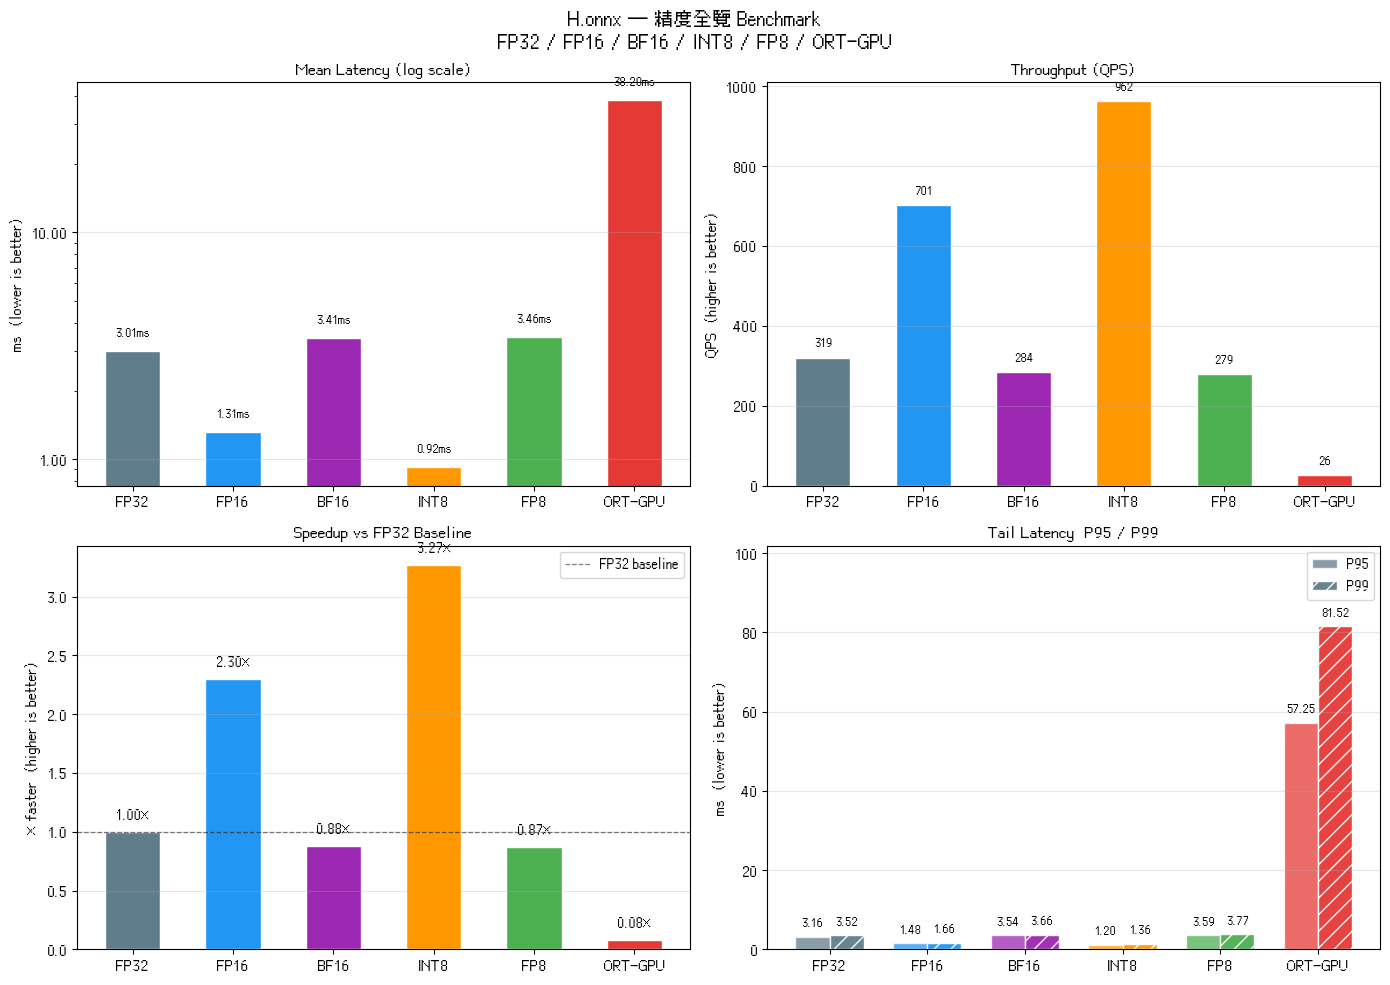

Saved → precision_sweep_results.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

labels     = df["精度"].tolist()
mean_vals  = df["Mean (ms)"].tolist()
qps_vals   = df["QPS"].tolist()
spd_vals   = df["vs FP32 (加速比)"].tolist()
p95_vals   = df["P95 (ms)"].tolist()
p99_vals   = df["P99 (ms)"].tolist()

PALETTE = ["#607D8B", "#2196F3", "#9C27B0", "#FF9800", "#4CAF50", "#E53935"]
COLORS  = PALETTE[:len(labels)]
x = np.arange(len(labels))
w = 0.35

has_tail = any(not np.isnan(v) for v in p95_vals)
has_acc  = df_acc is not None and len(df_acc) > 0

ncols = 2
nrows = 2 if not has_acc else 3
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))

def annotate(ax, bars, fmt="{:.2f}"):
    ymax = max((b.get_height() for b in bars if not np.isnan(b.get_height())), default=1)
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2, h + ymax * 0.02,
                    fmt.format(h), ha="center", va="bottom", fontsize=8, fontweight="bold")

def annotate_log(ax, bars, fmt="{:.2f}"):
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h) and h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h * 1.12,
                    fmt.format(h), ha="center", va="bottom", fontsize=8, fontweight="bold")

# ── Row 0, Col 0: Mean latency (log scale) ───────────────────────────────────
ax = axes[0, 0]
bars = ax.bar(x, mean_vals, color=COLORS, width=0.55, edgecolor="white")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
annotate_log(ax, bars, fmt="{:.2f}ms")
ax.set_title("Mean Latency (log scale)", fontsize=11)
ax.set_ylabel("ms  (lower is better)")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.grid(axis="y", alpha=0.3)

# ── Row 0, Col 1: Throughput ──────────────────────────────────────────────────
ax = axes[0, 1]
bars = ax.bar(x, qps_vals, color=COLORS, width=0.55, edgecolor="white")
annotate(ax, bars, fmt="{:.0f}")
ax.set_title("Throughput (QPS)", fontsize=11)
ax.set_ylabel("QPS  (higher is better)")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.grid(axis="y", alpha=0.3)

# ── Row 1, Col 0: Speedup vs FP32 ────────────────────────────────────────────
ax = axes[1, 0]
bars = ax.bar(x, spd_vals, color=COLORS, width=0.55, edgecolor="white")
ax.axhline(1.0, color="black", linestyle="--", linewidth=0.9, alpha=0.5, label="FP32 baseline")
for bar, val in zip(bars, spd_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(spd_vals) * 0.02,
            f"{val:.2f}×", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Speedup vs FP32 Baseline", fontsize=11)
ax.set_ylabel("× faster  (higher is better)")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# ── Row 1, Col 1: Tail Latency P95/P99 (linear, from-zero) ───────────────────
ax = axes[1, 1]
if has_tail:
    valid = [v for v in p95_vals + p99_vals if not np.isnan(v) and v > 0]
    ymax  = max(valid) if valid else 1.0
    bp95 = ax.bar(x - w/2, p95_vals, w, label="P95", color=COLORS, alpha=0.75, edgecolor="white")
    bp99 = ax.bar(x + w/2, p99_vals, w, label="P99", color=COLORS, alpha=0.95, edgecolor="white", hatch="//")
    ax.set_ylim(0, ymax * 1.25)
    annotate(ax, list(bp95) + list(bp99), fmt="{:.2f}")
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "P95/P99 not available\n(trtexec 未輸出)",
            transform=ax.transAxes, ha="center", va="center", fontsize=11, color="gray")
ax.set_title("Tail Latency  P95 / P99", fontsize=11)
ax.set_ylabel("ms  (lower is better)")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.grid(axis="y", alpha=0.3)

# ── Row 2 (optional): Accuracy agreement ─────────────────────────────────────
if has_acc:
    ax_acc = axes[2, 0]
    acc_labels = df_acc["精度"].tolist()
    acc_vals   = df_acc["一致率 (%)"].tolist()
    ax_acc.bar(acc_labels, acc_vals,
               color=PALETTE[:len(acc_labels)], width=0.55, edgecolor="white")
    ax_acc.set_ylim(0, 110)
    ax_acc.axhline(100, color="green", linestyle="--", linewidth=0.9, alpha=0.5)
    for i, v in enumerate(acc_vals):
        if not np.isnan(v):
            ax_acc.text(i, v + 1.5, f"{v:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax_acc.set_title("與 ORT 預測一致率", fontsize=11)
    ax_acc.set_ylabel("%  (100% = 完全一致)")
    ax_acc.grid(axis="y", alpha=0.3)

    axes[2, 1].axis("off")

plt.suptitle("H.onnx — 精度全覽 Benchmark\nFP32 / FP16 / BF16 / INT8 / FP8 / ORT-GPU",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("precision_sweep_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → precision_sweep_results.png")